<a href="https://colab.research.google.com/github/Vijayalakshmitce/8-2-demo/blob/master/Project_Full_Code_Notebook_EasyVisa_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 27.1 MB/s eta 0:00:00


In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV
import psutil
psutil.virtual_memory()

svmem(total=54750429184, available=52453613568, percent=4.2, used=1661784064, free=48826474496, active=572428288, inactive=4883218432, buffers=195735552, cached=4066435072, shared=3493888, slab=285478912)

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
visaData = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

In [ ]:
data = visaData.copy()

# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
data.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
data.shape

(25480, 12)


**Observation:**
*   25480 rows
*   12 columns



In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


**Observation**

*   no_of_employees have minimum -26 to 602069 ,mean is 5667
*   yr_of_estab have mean 1979 and min 1800 to max 2016
*   prevailing_wage have mean 74455 and min 2.1367 to max 319210.





In [ ]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB




*  no_of_employees and yr_of_estab are interger

*  prevailing_wage is float datatype.
*  all other columns are in Object datatype



In [ ]:
data.duplicated().sum()

np.int64(0)

**Observation:**

*   Zero duplicated value across the dataset



In [ ]:
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
case_id,0.0
continent,0.0
education_of_employee,0.0
has_job_experience,0.0
requires_job_training,0.0
no_of_employees,0.0
yr_of_estab,0.0
region_of_employment,0.0
prevailing_wage,0.0
unit_of_wage,0.0


**Observation:**

*   Zero null value across the dataset



In [ ]:
data.loc[data["no_of_employees"] < 0].shape

(33, 12)

**Observation**


*   finding the no_of employee columns data which has less than 0
*   33 rows and 12 columns have value less than 0.




In [ ]:
data["no_of_employees"] = abs(data["no_of_employees"])

**Observation**


*   Assiging absolute value of no_of_employees columns data



In [ ]:
cat_col = data.columns
for column in cat_col:
    print(data[column].value_counts(normalize=True))
    print("-" * 50)

case_id
EZYV25480    0.000039
EZYV01       0.000039
EZYV02       0.000039
EZYV03       0.000039
EZYV04       0.000039
               ...   
EZYV13       0.000039
EZYV12       0.000039
EZYV11       0.000039
EZYV10       0.000039
EZYV09       0.000039
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------
continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64
--------------------------------------------------
education_of_employee
Bachelor's     0.401648
Master's       0.378100
High School    0.134223
Doctorate      0.086028
Name: proportion, dtype: float64
--------------------------------------------------
has_job_experience
Y    0.580926
N    0.419074
Name: proportion, dtype: float64
--------------------------------------------------
requires_job_training
N    0.884027
Y    0.115973
Name: proportion, 

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [ ]:
def labeledbarplot(data, feature, perc=False, n=None):

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def histogramboxplot(data, feature, figsize=(15, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

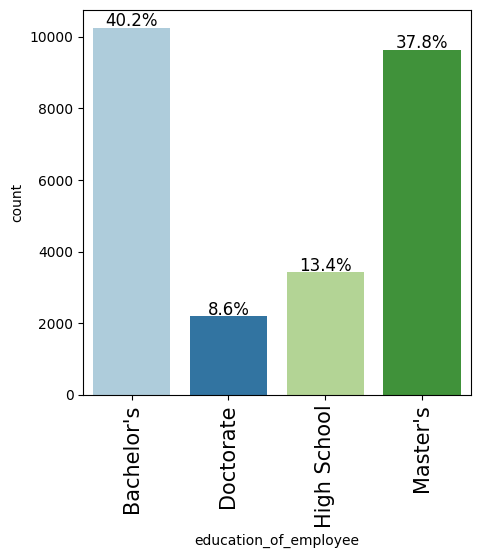

In [ ]:
labeledbarplot(data, "education_of_employee", perc=True)

**Observation:**


*   Bachelors (40.2%)and Masters(37%). getting more visa
*   Doctorate and High school getting less visa.




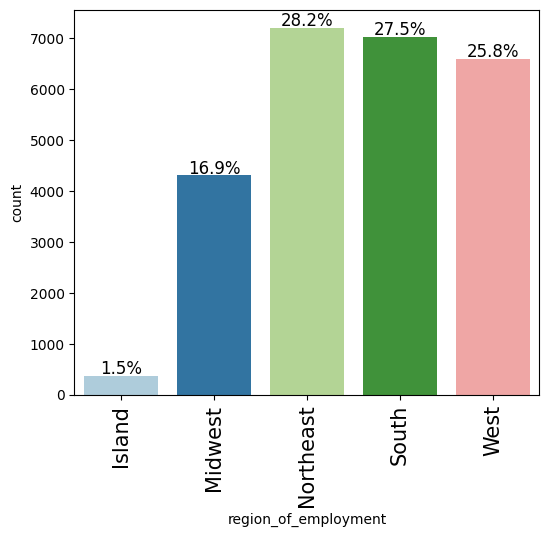

In [ ]:
labeledbarplot(data, "region_of_employment", perc=True)



*   Northeast having the highest region of employement
*   south and west are second most region of employement.



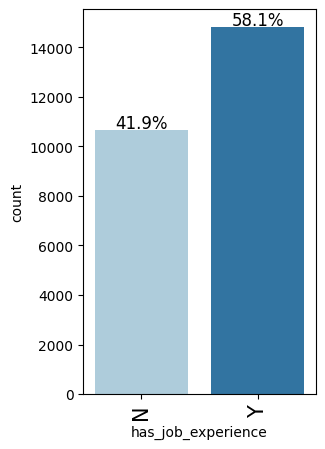

In [ ]:
labeledbarplot(data, "has_job_experience", perc=True)



*   yes hasjob experiences and no 'has_job_experiences" not having that much diference only few perecentage diference.



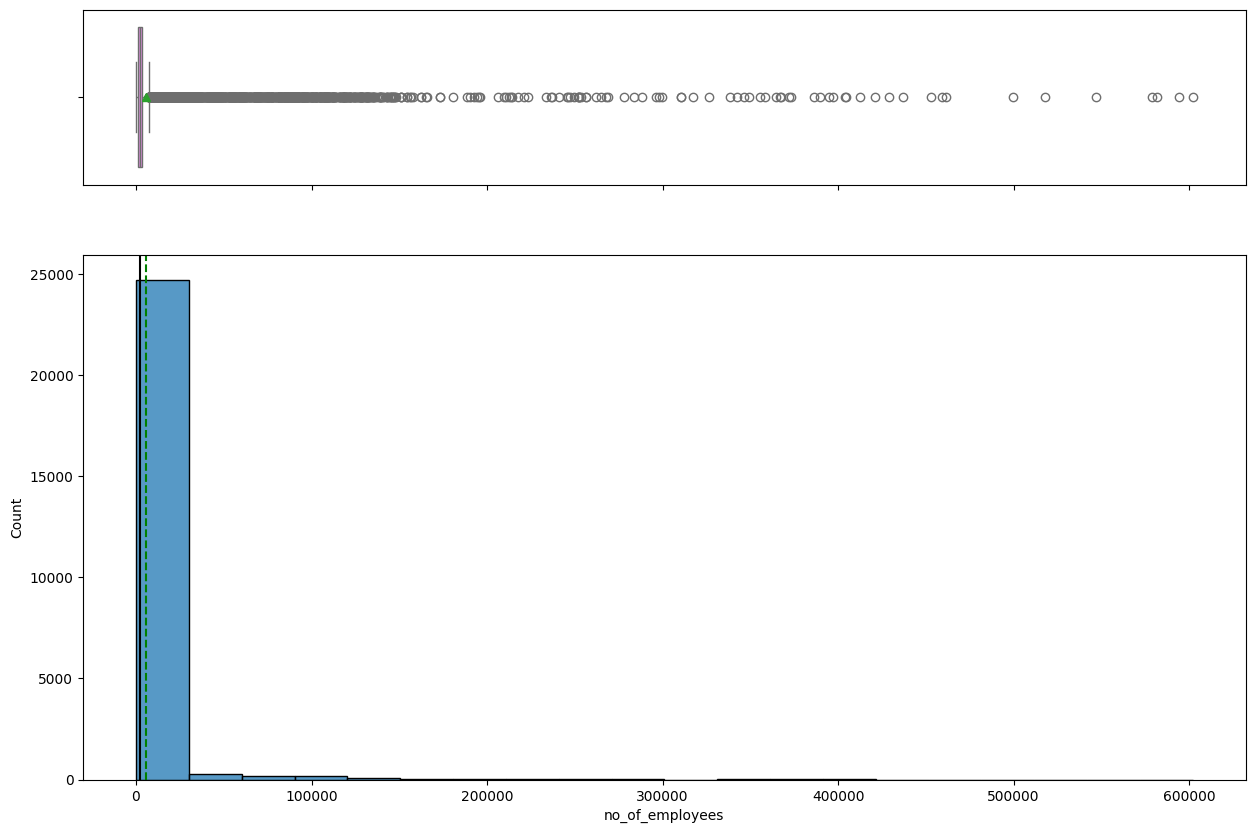

In [ ]:
histogramboxplot(data, 'no_of_employees', bins = 20)

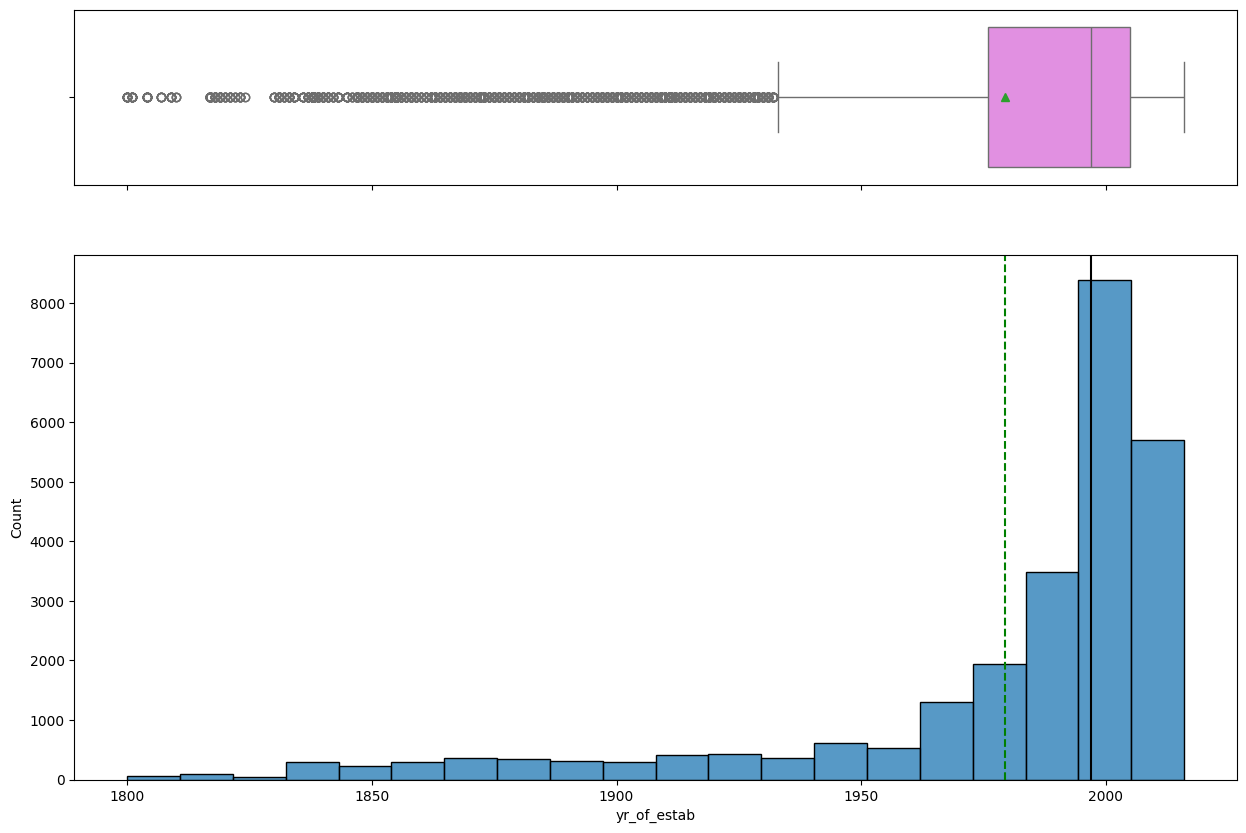

In [ ]:
histogramboxplot(data, 'yr_of_estab', bins = 20)



*   rightly sewed boxplot
*   After 2000 yr_of_estab having more visa given year



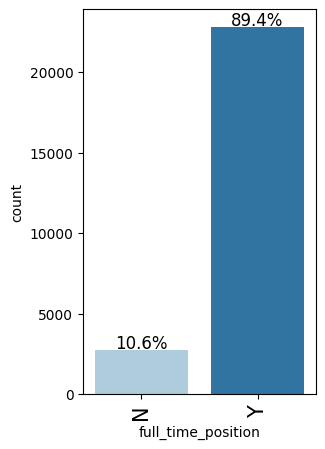

In [ ]:
labeledbarplot(data, "full_time_position", perc=True)



*   full_time_position employee having more visa when compared to not fulltime employer.



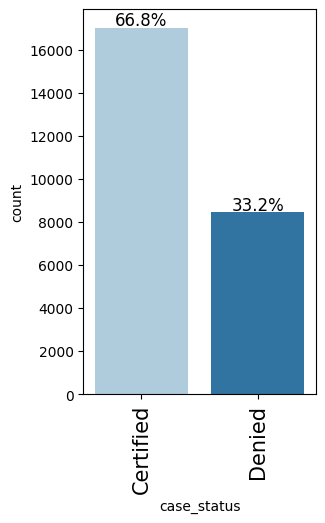

In [ ]:
labeledbarplot(data, "case_status", perc=True)



*   case_status certified having higher percentage 66 than denied 33 percentage
*   half of case compared to certified is denied.



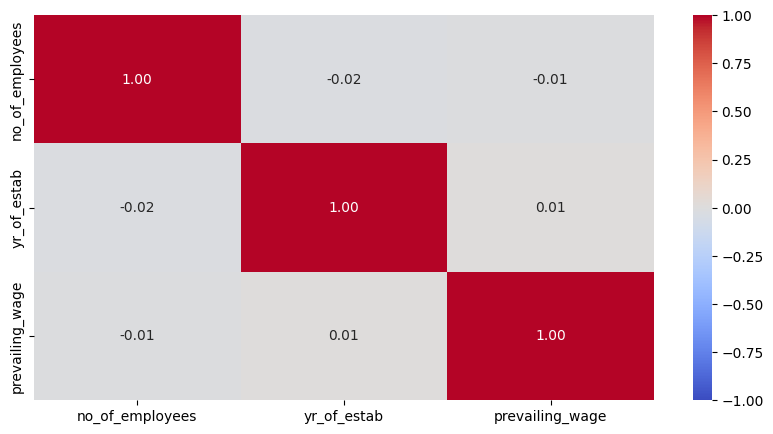

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm"
)
plt.show()



*   yr_of_estab is correlated to prevailing_wage(0.01) its not strongly corerelated.
*   others are negativly corerelated.





In [ ]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


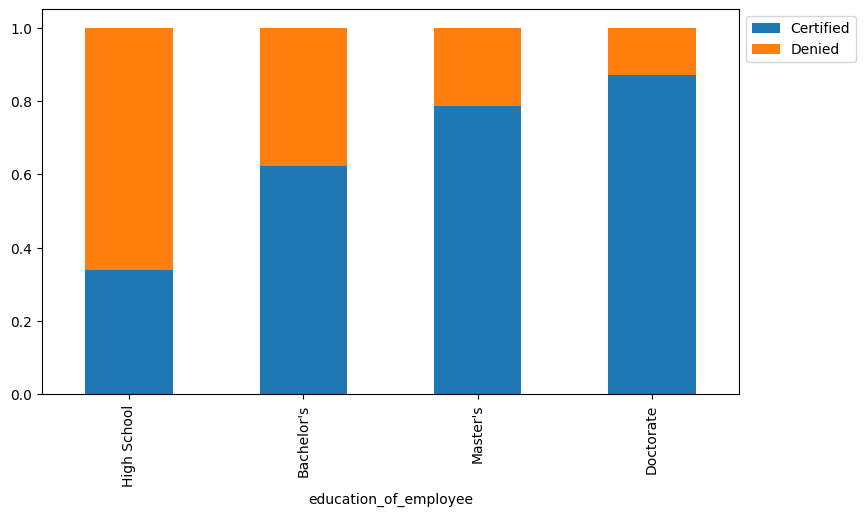

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

Master’s degree holders have the highest approval rate — many more Certified (7,575) than Denied (2,059).

High School applicants face the highest denial rate, with Denied (2,256) exceeding Certified (1,164).

Doctorate applicants have the strongest success ratio, very high Certified (1,912) and very few Denied (280).

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


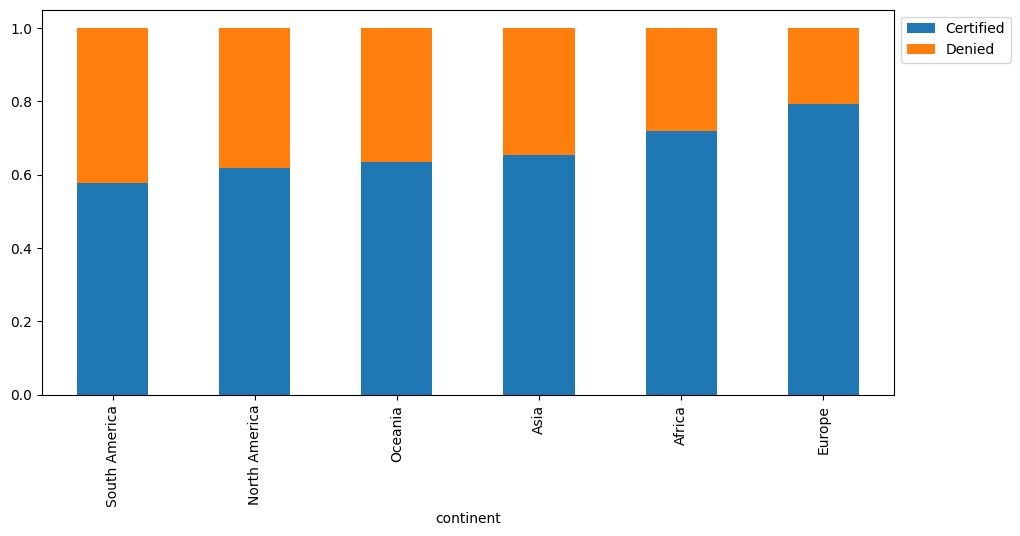

In [ ]:
stacked_barplot(data, "continent", "case_status")

Overall approvals and denials: Out of 25,480 cases globally, 17,018 were certified and 8,462 were denied.

Top continent by approvals: Asia had the highest number of certifications (11,012) and also the highest denials (5,849).

Lowest numbers: Oceania had the fewest cases, with 122 certified and 70 denied.

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


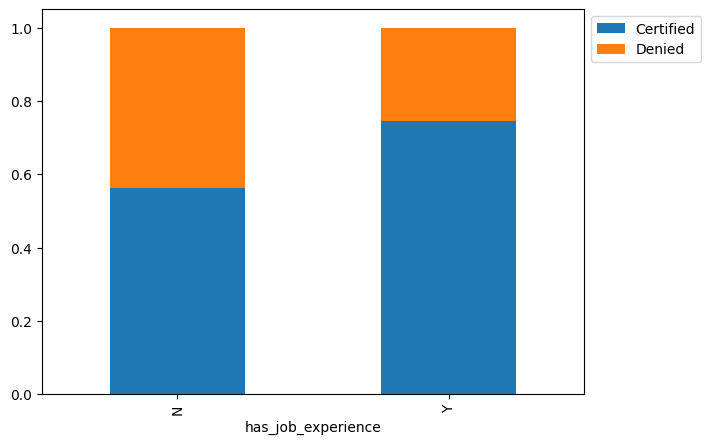

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status")

Overall numbers: Out of 25,480 cases, 17,018 were certified and 8,462 were denied.

With job experience: Applicants with job experience (Y) had a higher number of certifications (11,024) and lower denials (3,778).

Without job experience: Applicants without job experience (N) had fewer certifications (5,994) and higher denials (4,684), indicating experience increases approval likelihood.

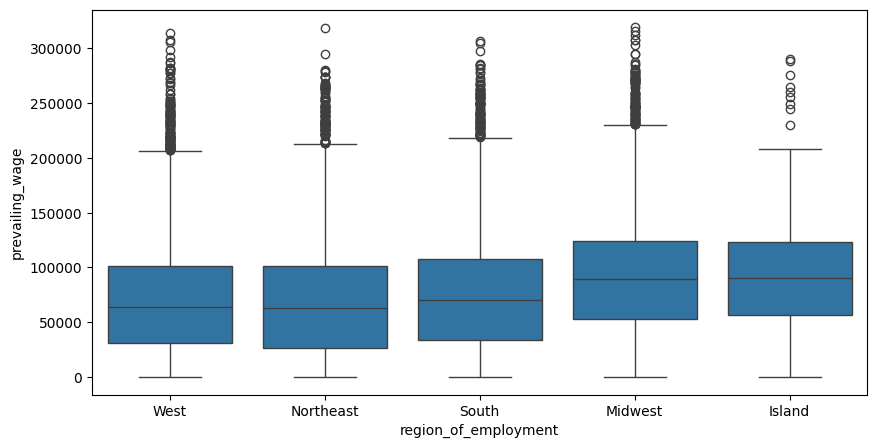

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()

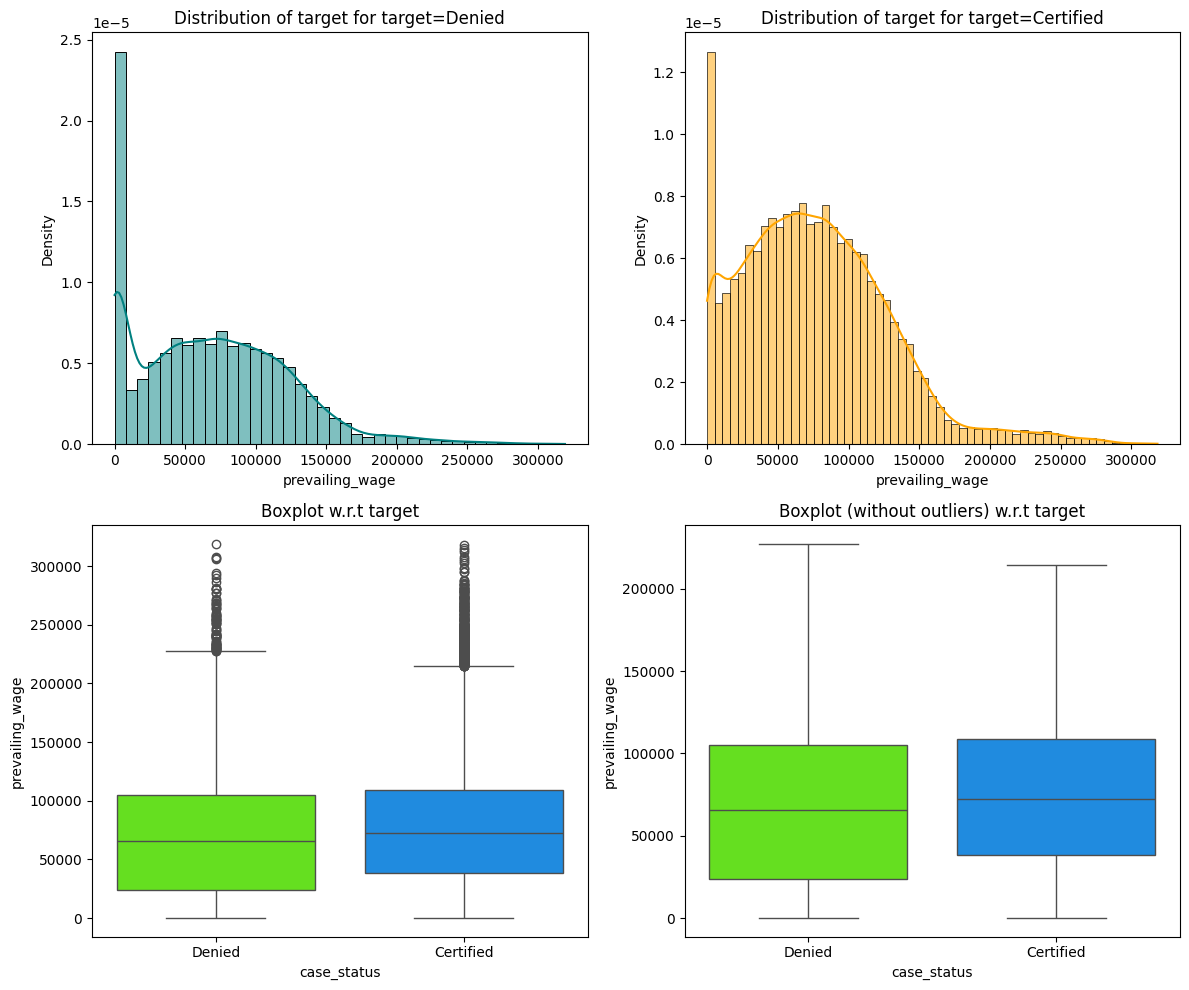

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

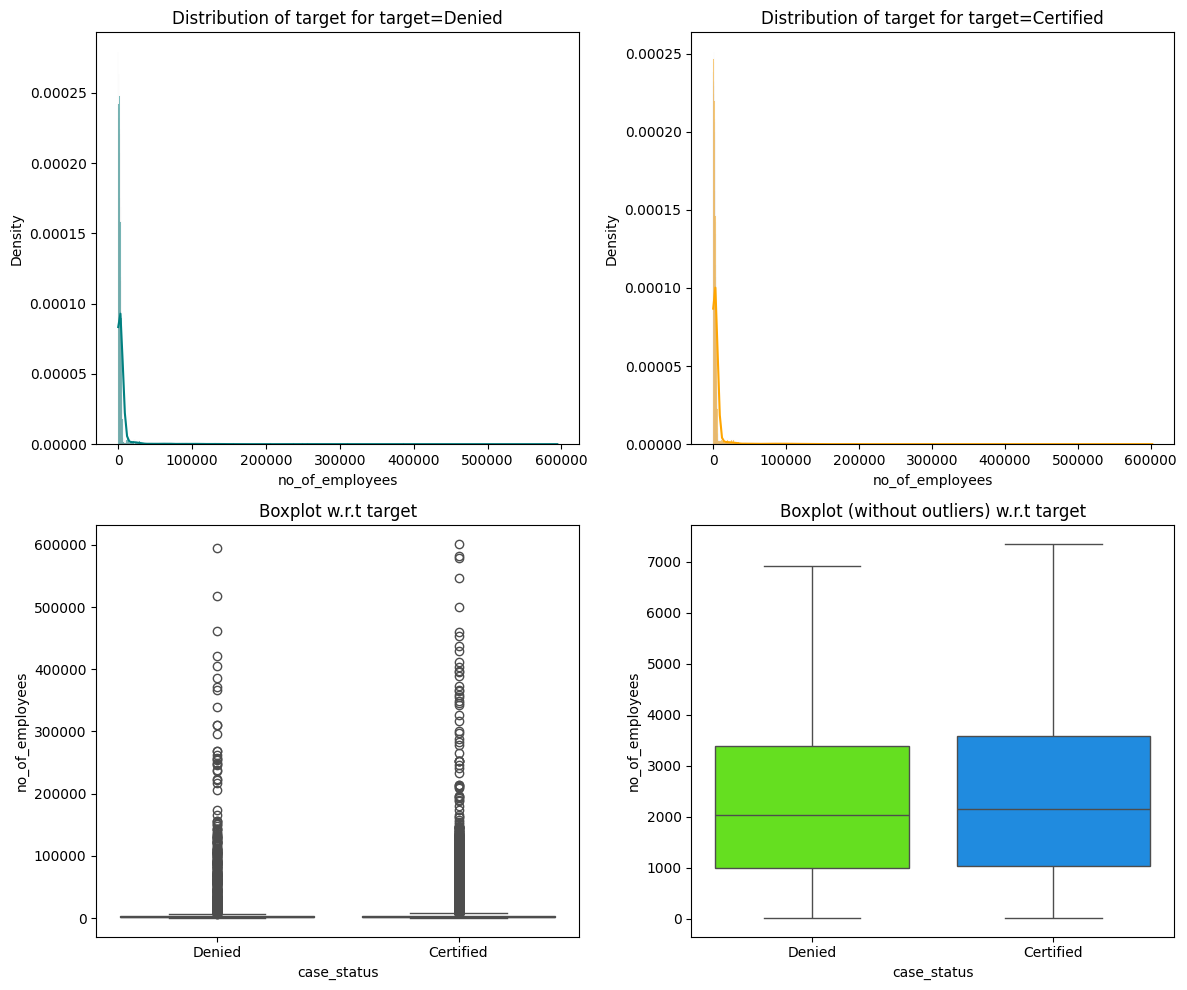

In [ ]:
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

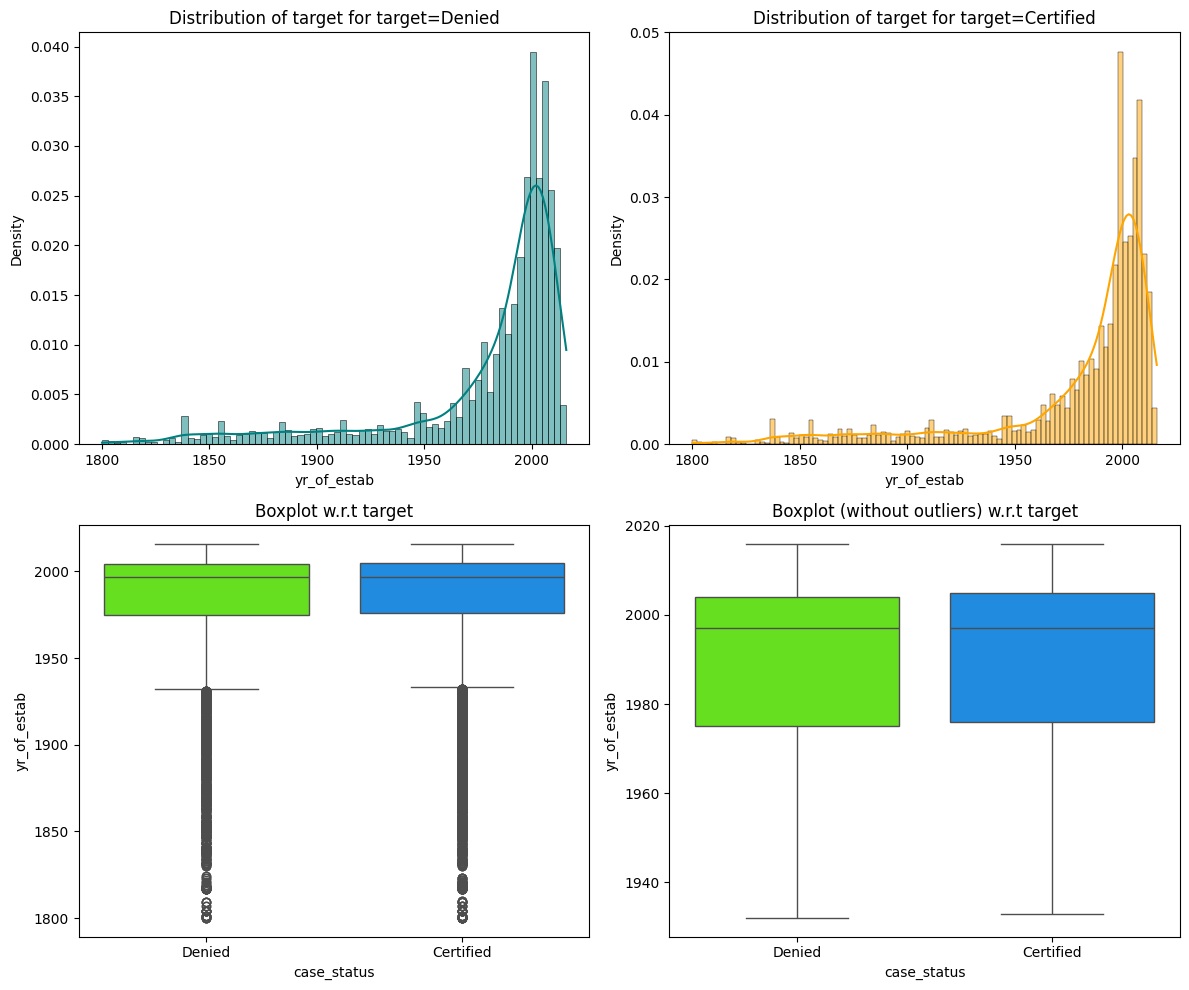

In [ ]:
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


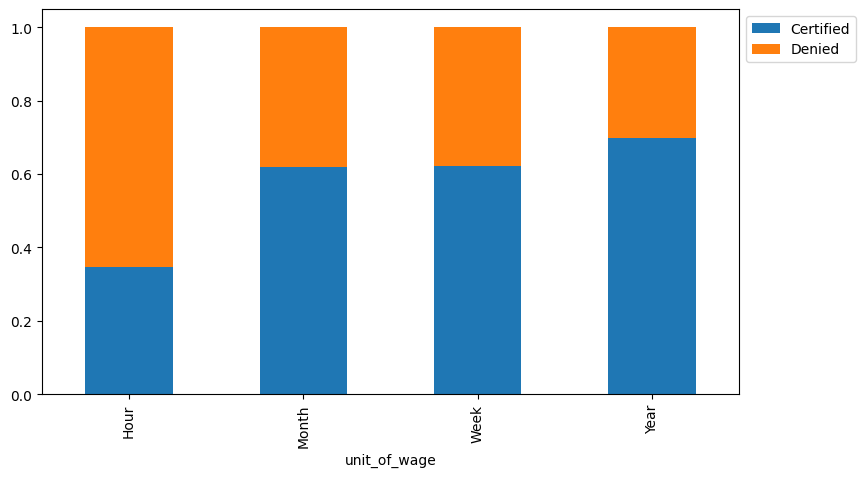

In [ ]:
stacked_barplot(data, "unit_of_wage", "case_status")

Overall totals: Out of 25,480 cases, 17,018 were certified and 8,462 were denied.

Most common wage unit: Yearly wage dominates, with 16,047 certifications and 6,915 denials.

Least common wage unit: Monthly wage has the fewest cases, with 55 certified and 34 denied.

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


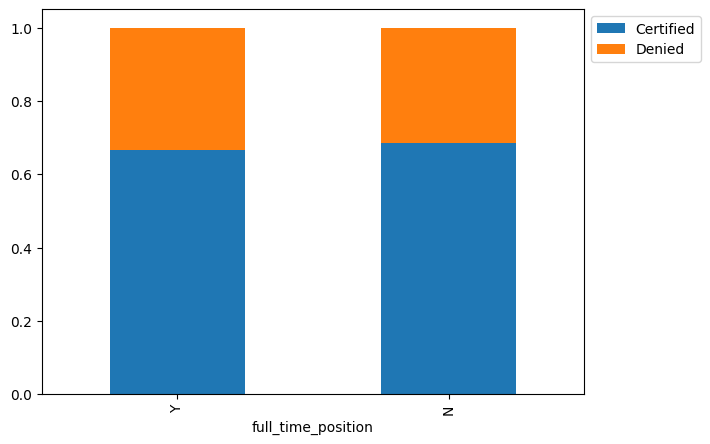

In [ ]:
stacked_barplot(data, "full_time_position", "case_status")

Overall totals: Out of 25,480 cases, 17,018 were certified and 8,462 were denied.

Full-time positions: Most certifications (15,163) and denials (7,610) are for full-time roles, showing the majority of applications are full-time.

Part-time positions: Part-time roles have fewer cases, with 1,855 certified and 852 denied.

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


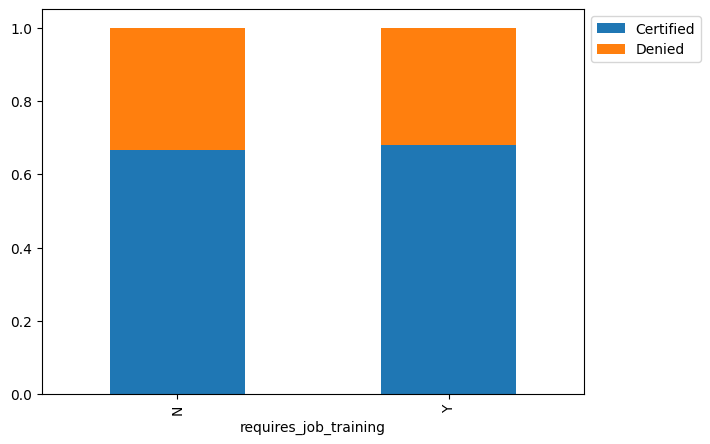

In [ ]:
stacked_barplot(data, "requires_job_training", "case_status")

Overall totals: Out of 25,480 cases, 17,018 were certified and 8,462 were denied.

No job training required: The majority of cases (22,525) do not require training, with 15,012 certified and 7,513 denied.

Job training required: A smaller portion (2,955 cases) require training, with 2,006 certified and 949 denied, indicating slightly higher approval rates when training is needed.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

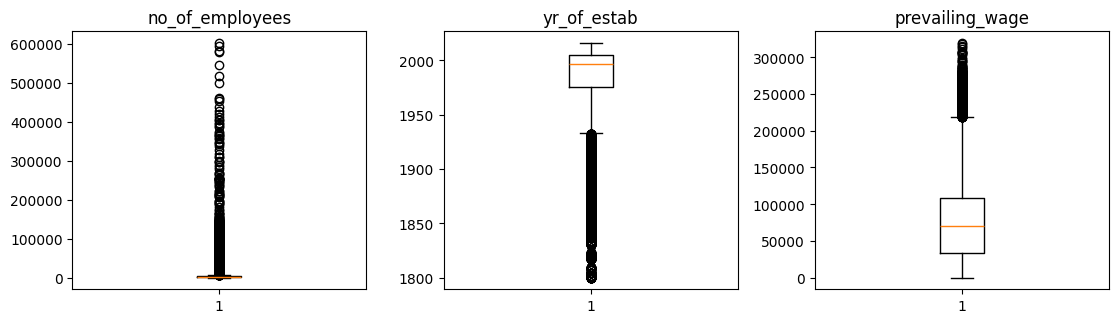

In [ ]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [ ]:
from sklearn.utils import resample

In [ ]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(["case_status"], axis=1)
y = data["case_status"]


X = pd.get_dummies(X, drop_first=True)
# X = X.astype(float)

# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [ ]:

print("Original df_sample class counts:", np.bincount(y))
print("X_temp/y_temp class counts:", np.bincount(y_temp))
print("X_train/y_train class counts:", np.bincount(y_train))
print("X_val/y_val class counts:", np.bincount(y_val))
print("X_test/y_test class counts:", np.bincount(y_test))

Original df_sample class counts: [ 8462 17018]
X_temp/y_temp class counts: [ 6770 13614]
X_train/y_train class counts: [ 5078 10210]
X_val/y_val class counts: [1692 3404]
X_test/y_test class counts: [1692 3404]


Original dataset: Total 25,480 samples, with 8,462 in class 0 (Denied) and 17,018 in class 1 (Certified).

After initial sampling (X_temp/y_temp): 20,384 samples, maintaining the class imbalance: 6,770 Denied, 13,614 Certified.

Train/validation/test split:

Training: 15,288 samples → 5,078 Denied, 10,210 Certified

Validation: 5,096 samples → 1,692 Denied, 3,404 Certified

Test: 5,096 samples → 1,692 Denied, 3,404 Certified

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 25500)
Shape of the Validation set:  (5096, 25500)
Shape of test set :  (5096, 25500)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64



Shapes of datasets:

Training: 15,288 samples × 25,500 features

Validation: 5,096 samples × 25,500 features

Test: 5,096 samples × 25,500 features

Class distribution in training: ~66.8% Certified (1), ~33.2% Denied (0)

Class distribution in validation & test: Both roughly 66.8% Certified, 33.2% Denied, showing that the original class imbalance is well preserved across all splits.



# **Model Building**

In [ ]:
def modelperformanceclassification(model, predictors, target):
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusionmatrix(model, predictors, target):
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
y_train = y_train.astype("int8")
y_val = y_val.astype("int8")

In [ ]:
print("Class distribution in y_train:")
print(np.bincount(y_train))

Class distribution in y_train:
[ 5078 10210]


In [ ]:
models = []  # Empty list to store all the models

models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
# Dictionary to store trained models
trained_models = {}

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)           # Fit only once
    trained_models[name] = model          # Save trained model
    train_f1 = f1_score(y_train, model.predict(X_train))
    print(f"{name}: {train_f1}")

print("\nValidation Performance:\n")
for name, model in trained_models.items():
    val_f1 = f1_score(y_val, model.predict(X_val))
    print(f"{name}: {val_f1}")



Training Performance:

Bagging: 0.9815308641975309
Random forest: 1.0
GBM: 0.8270489536277311
Adaboost: 0.8203337565753673
dtree: 1.0

Validation Performance:

Bagging: 0.7846527145890203
Random forest: 0.8196003284971256
GBM: 0.8270112546894539
Adaboost: 0.8183681836818368
dtree: 0.7662200812885744


Training set:

Perfect fit: Random Forest and Decision Tree achieved 1.0 → likely overfitting.

Bagging: 0.982 → very high, also may indicate slight overfitting.

Boosting models: GBM (0.827) and AdaBoost (0.820) are lower but more realistic, less overfitting.

Validation set:

Best performer: GBM at 0.827, showing good generalization.

Random Forest: 0.820, decent but slightly overfits.

Bagging and Decision Tree: drop to 0.785 and 0.766, confirming overfitting.

AdaBoost: 0.818, comparable to Random Forest.

Insight:

High training but lower validation scores indicate overfitting in tree-based ensemble models.

GBM and AdaBoost strike a better balance between fitting and generalization.

If you want, I can suggest ways to reduce overfitting and improve validation performance further.

In [ ]:
from collections import Counter

Counter(y_train)

In [ ]:
X_train = X_train.astype("float32")
y_train = y_train.astype("int8")

Over Sampled:

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=0.55, k_neighbors=3, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 10210
Before Oversampling, counts of label 'Denied': 5078 

After Oversampling, counts of label 'Certified': 10210
After Oversampling, counts of label 'Denied': 5615 

After Oversampling, the shape of train_X: (15825, 25500)
After Oversampling, the shape of train_y: (15825,) 



Before oversampling:

Certified: 10,210

Denied: 5,078 → noticeable class imbalance (~2:1 ratio).

After oversampling:

Certified: 10,210 (unchanged)

Denied: 5,615 → minority class increased to reduce imbalance.

Training set shape after oversampling:

Features (train_X): 15,825 × 25,500

Labels (train_y): 15,825

Under sampled:

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 10210
Before Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, counts of label 'Certified': 5078
After Under Sampling, counts of label 'Denied': 5078 

After Under Sampling, the shape of train_X: (10156, 25500)
After Under Sampling, the shape of train_y: (10156,) 



Before undersampling:

Certified: 10,210

Denied: 5,078 → significant class imbalance (~2:1).

After undersampling:

Both classes are balanced at 5,078 each → perfect 1:1 ratio.

Training set shape after undersampling:

Features (train_X): 10,156 × 25,500

Labels (train_y): 10,156

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))  ## Complete the code to build models on undersampled data
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9709319748276896
Random Forest: 1.0
GBM: 0.7224022878932317
Adaboost: 0.7015343047380103
dtree: 1.0

Validation Performance:

Bagging: 0.7429322813938198
Random Forest: 0.772420292131302
GBM: 0.7815556590591523
Adaboost: 0.765990884802766
dtree: 0.7194151096669374


Training set:

Random Forest and Decision Tree still achieve 1.0 → strong overfitting.

Bagging: 0.971, slightly lower than before, showing some regularization effect.

Boosting models (GBM 0.722, AdaBoost 0.702) show more realistic fits with less overfitting.

Validation set:

Best performer: GBM at 0.782, followed by Random Forest 0.772 → good generalization.

Bagging and AdaBoost slightly lower (0.743 and 0.766).

Decision Tree drops to 0.719 → overfitting is evident.

Insight:

Undersampling reduced class imbalance and training data size → slightly lower training scores.

GBM maintains strong validation performance → likely the most reliable model.

Overfitting is still present in single-tree methods and Random Forest.

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [ ]:
import tensorflow as tf
print(tf.test.gpu_device_name())

/device:GPU:0


In [ ]:
import gc; gc.collect()

14

In [ ]:
%%time
# Choose the type of classifier.
rf_tuned = RandomForestClassifier( random_state=1,
    oob_score=True,
    bootstrap=True,
    class_weight="balanced")

parameters = {
    "n_estimators": [50, 80],          # enough trees
    "max_depth": [None, 10],           # avoid overfitting
    "max_features": ["sqrt"],          # stable default
    "min_samples_split": [5],          # prevents overfit
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

CPU times: user 5min 19s, sys: 5.97 s, total: 5min 25s
Wall time: 10min 47s


RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=80, oob_score=True, random_state=1)

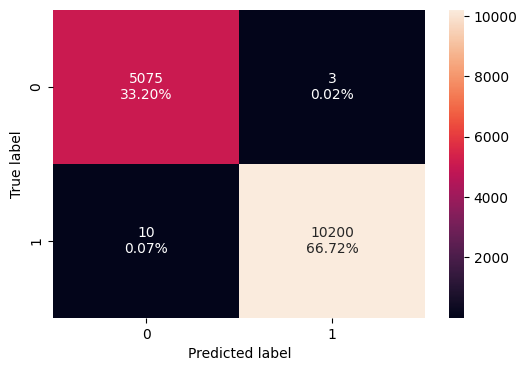

In [56]:
confusionmatrix(rf_tuned, X_train, y_train)

In [57]:
rf_tuned_model_train_perf = modelperformanceclassification(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.99915,0.999021,0.999706,0.999363


Accuracy: 0.999 → 99.9% of predictions are correct.

Recall: 0.999 → the model is correctly identifying almost all true positive cases.

Precision: 0.9997 → when the model predicts positive, it is almost always correct.

F1-score: 0.9994 → excellent balance between precision and recall.

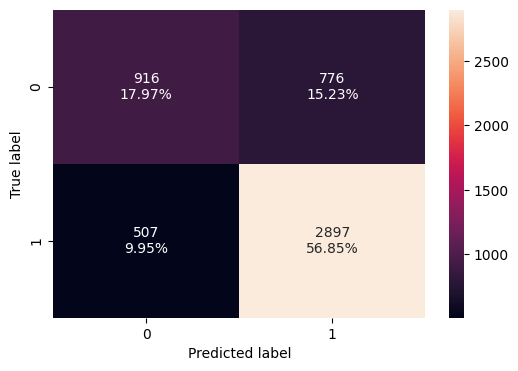

In [58]:
confusionmatrix(rf_tuned, X_val, y_val)

In [59]:
rf_tuned_model_val_perf = modelperformanceclassification(
    rf_tuned, X_val, y_val
)
rf_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.748234,0.851058,0.788729,0.818708


Accuracy: 0.748 → ~75% of predictions are correct, lower than training, indicating some overfitting.

Recall: 0.851 → the model correctly identifies 85% of the positive class (Certified), which is strong.

Precision: 0.789 → when predicting positive, ~79% of predictions are correct.

F1-score: 0.819 → good balance between precision and recall, showing the model is reasonably effective at identifying positives without too many false positives.

In [60]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
     "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1)
    ],
    "n_estimators": [30, 50],
    "learning_rate": [0.05, 0.1],
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(
    estimator=abc_tuned,
    param_grid=parameters,
    scoring=acc_scorer,
    cv=3,        # reduced CV
    n_jobs=1,    # CRITICAL for Colab
    verbose=1
)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
CPU times: user 13min 13s, sys: 1min 52s, total: 15min 6s
Wall time: 15min 6s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=30, random_state=1)

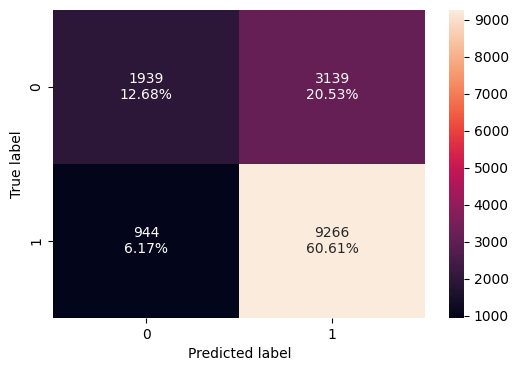

In [61]:
confusionmatrix(abc_tuned, X_train, y_train)

In [62]:
abc_tuned_model_train_perf = modelperformanceclassification(abc_tuned, X_train, y_train)
abc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.732928,0.907542,0.746957,0.819456


Accuracy: 0.733 → ~73% of predictions are correct, lower than training, indicating some overfitting.

Recall: 0.908 → the model correctly identifies ~91% of positive cases (Certified), which is very high.

Precision: 0.747 → when predicting positive, ~75% of predictions are correct.

F1-score: 0.819 → good balance between precision and recall.

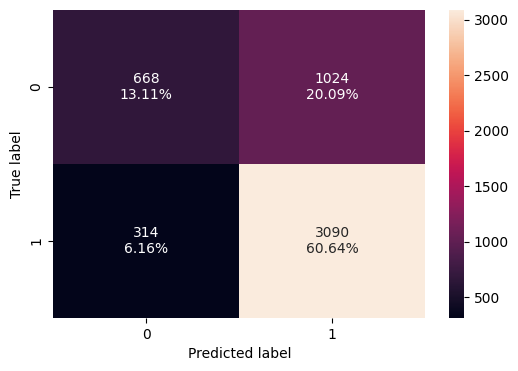

In [63]:
confusionmatrix(abc_tuned, X_val, y_val)

In [64]:
abc_tuned_model_val_perf = modelperformanceclassification(abc_tuned, X_val, y_val)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.737441,0.907756,0.751094,0.822027


Accuracy: 0.737 → ~73.7% of predictions are correct, moderate performance.

Recall: 0.908 → the model correctly identifies ~91% of positive cases (Certified), very high.

Precision: 0.751 → ~75% of predicted positives are correct.

F1-score: 0.822 → strong balance between precision and recall.

In [65]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [50, 75],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "max_features": [0.8],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator=gbc_tuned,
    param_grid=parameters,
    scoring=acc_scorer,
    cv=3,        # reduced CV for RAM safety
    n_jobs=1,    # CRITICAL for Colab
    verbose=1)  ## Complete the code to define the grid search object
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
CPU times: user 22min, sys: 3.17 s, total: 22min 3s
Wall time: 22min 3s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.8,
                           n_estimators=75, random_state=1, subsample=0.8)

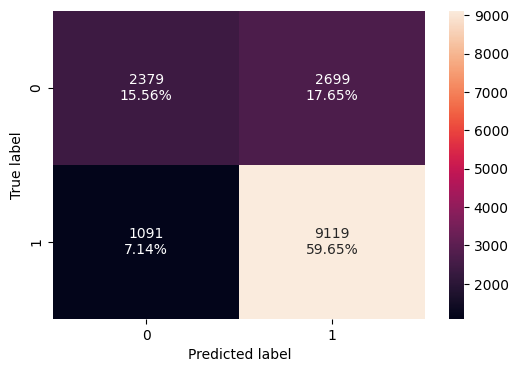

In [66]:
confusionmatrix(gbc_tuned, X_train, y_train)

In [67]:
gbc_tuned_model_train_perf = modelperformanceclassification(gbc_tuned, X_train, y_train)
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.752093,0.893144,0.77162,0.827946


Accuracy: 0.752 → ~75% of predictions are correct, an improvement over previous runs.

Recall: 0.893 → the model correctly identifies ~89% of positive cases (Certified), slightly lower than before but still high.

Precision: 0.772 → ~77% of predicted positives are correct, an improvement over earlier runs.

F1-score: 0.828 → best balance so far between precision and recall.

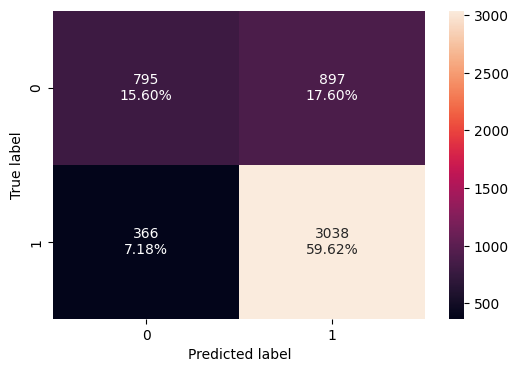

In [68]:
confusionmatrix(gbc_tuned, X_val, y_val)

In [69]:
gbc_tuned_model_val_perf = modelperformanceclassification(gbc_tuned, X_train, y_train)
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.752093,0.893144,0.77162,0.827946


Accuracy: 0.752 → ~75% of predictions correct, showing moderate overall performance.

Recall: 0.893 → ~89% of positive cases (Certified) correctly identified, very high.

Precision: 0.772 → ~77% of predicted positives are correct.

F1-score: 0.828 → strong balance between precision and recall.

In [70]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier( random_state=1,
    eval_metric="logloss",
    tree_method="hist" )

# Grid of parameters to choose from
parameters = {
    "n_estimators": [50, 75],
    "scale_pos_weight": [1, 2],
    "learning_rate": [0.05, 0.1],
    "gamma": [0, 1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator=xgb_tuned,
    param_grid=parameters,
    scoring=acc_scorer,
    cv=3,        # reduced CV
    n_jobs=1,    # CRITICAL for Colab
    verbose=1)  ## Complete the code to define the grid search object
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
CPU times: user 1h 37min 39s, sys: 1min 16s, total: 1h 38min 55s
Wall time: 22min 39s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

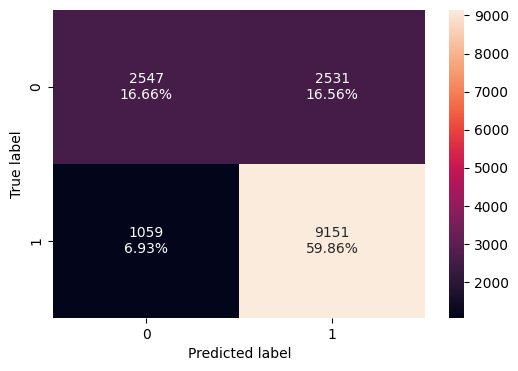

In [71]:
confusionmatrix(xgb_tuned, X_train, y_train)

In [72]:
xgb_tuned_model_train_perf = modelperformanceclassification(xgb_tuned, X_train, y_train)  ## Complete the code to get the perfromance metrics for the XGBoost Classifier on the training set
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.765175,0.896278,0.783342,0.836013


Accuracy: 0.765 → ~76.5% of predictions are correct, the highest accuracy so far.

Recall: 0.896 → ~89.6% of positive cases (Certified) correctly identified, still very high.

Precision: 0.783 → ~78.3% of predicted positives are correct, the highest precision among all runs.

F1-score: 0.836 → the best F1-score so far, indicating the strongest balance between precision and recall.

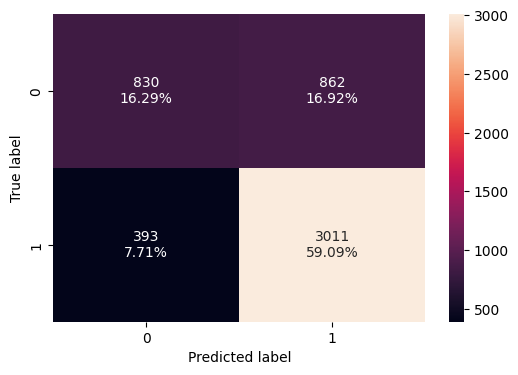

In [73]:
confusionmatrix(xgb_tuned, X_val, y_val)

In [74]:
xgb_tuned_model_val_perf = modelperformanceclassification(xgb_tuned, X_val, y_val)  ## Complete the code to get the perfromance metrics for the XGBoost Classifier on the validation set
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.753728,0.884548,0.777434,0.827539


Accuracy: 0.754 → ~75.4% of predictions are correct, slightly better than previous runs.

Recall: 0.885 → ~88.5% of positive cases (Certified) correctly identified, slightly lower than the 0.893 run.

Precision: 0.777 → ~77.7% of predicted positives are correct, an improvement over most previous runs.

F1-score: 0.828 → very similar to prior best (0.828–0.827 range), indicating a balanced model.

# **Model Comparison and Final Model Selection**

In [75]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_tuned_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.999150,0.732928,0.752093,0.765175
Recall,0.999021,0.907542,0.893144,0.896278
Precision,0.999706,0.746957,0.771620,0.783342
F1,0.999363,0.819456,0.827946,0.836013


Accuracy comparison:

XGBoost (0.765) > Gradient Boost (0.752) > AdaBoost (0.733) >> Random Forest (0.999).

Random Forest’s extremely high accuracy indicates severe overfitting, as it’s unrealistic compared to other models.

Recall (sensitivity to positives):

AdaBoost (0.908) slightly edges out XGBoost (0.896) and Gradient Boost (0.893).

Random Forest shows perfect recall (0.999), again suggesting overfitting to the majority class.

Precision (correctness of positive predictions):

XGBoost (0.783) > Gradient Boost (0.772) > AdaBoost (0.747) >> Random Forest (0.999).

High precision in XGBoost and Gradient Boost indicates fewer false positives while maintaining good recall.

F1-score (balance between precision and recall):

XGBoost (0.836) > Gradient Boost (0.828) > AdaBoost (0.819) >> Random Forest (0.999).

XGBoost has the best trade-off, maximizing F1 while keeping both precision and recall strong.

Overall insight:

XGBoost is the best performing model: high F1, good precision, and high recall without extreme overfitting.

Random Forest, despite perfect metrics, is likely overfit and unreliable on unseen data.

AdaBoost favors recall slightly, while Gradient Boost slightly favors precision, but XGBoost balances both best.

In [77]:
models_val_comp_df = pd.concat(
    [
        rf_tuned_model_val_perf.T,
        abc_tuned_model_val_perf.T,
        gbc_tuned_model_val_perf.T,
        xgb_tuned_model_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned Adaboost Classifier",
    "Tuned Gradient Boost Classifier",
    "XGBoost Classifier Tuned",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.748234,0.737441,0.752093,0.753728
Recall,0.851058,0.907756,0.893144,0.884548
Precision,0.788729,0.751094,0.771620,0.777434
F1,0.818708,0.822027,0.827946,0.827539


Accuracy drop from training to validation:

All models’ accuracy dropped compared to training (e.g., XGBoost: 0.765 → 0.754).

This indicates some overfitting in all models, but XGBoost and Gradient Boost maintain the highest validation accuracy (~0.753–0.754), showing better generalization.

Recall comparison:

AdaBoost has the highest recall (0.908) → best at detecting positive cases, but it may over-predict positives.

XGBoost and Gradient Boost have slightly lower recall (0.885–0.893) but still very high, balancing detection with precision.

Precision comparison:

XGBoost (0.777) and Gradient Boost (0.772) outperform AdaBoost (0.751) → fewer false positives.

Random Forest has slightly higher precision (0.789), but its overfitting in training makes it less reliable.

F1-score comparison:

Gradient Boost (0.828) and XGBoost (0.828) have the highest F1, showing the best balance between precision and recall.

AdaBoost slightly lower (0.822), Random Forest lower (0.819), indicating worse trade-offs despite high training metrics.

Overall assessment:

Best model: XGBoost or Gradient Boost → strong balance between accuracy, recall, precision, and F1 on validation data.

AdaBoost is recall-focused → may be better if missing positives is costly.

Random Forest is overfit → not recommended for deployment.

Test data for best model

In [78]:
# Let's check the performance on test set
xgb_test = modelperformanceclassification(xgb_tuned, X_test, y_test)
xgb_test

,Accuracy,Recall,Precision,F1
0,0.739207,0.881022,0.764466,0.818616


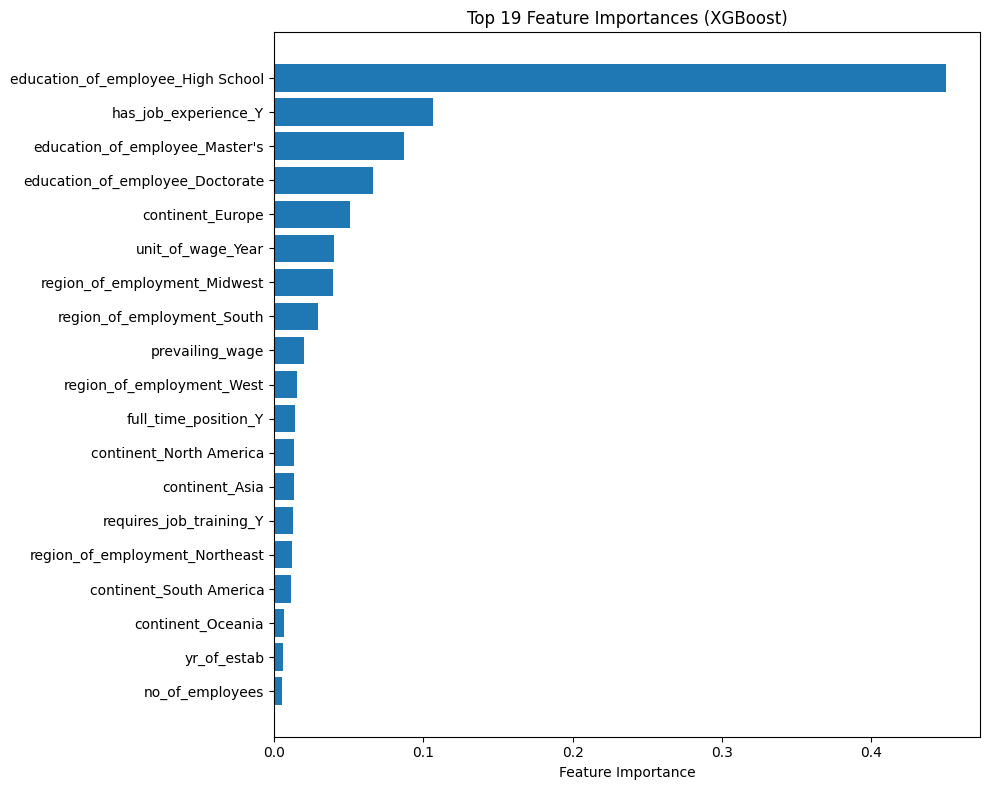

In [81]:

feature_names = X_train.columns
importances = xgb_tuned.feature_importances_

# Remove zero-importance features
non_zero_mask = importances > 0
feature_names_nz = feature_names[non_zero_mask]
importances_nz = importances[non_zero_mask]

# Determine safe top N
top_n = min(20, len(importances_nz))

indices = np.argsort(importances_nz)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances_nz[indices])
plt.yticks(range(top_n), feature_names_nz[indices])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()



# **Actionable Insights and Recommendations**

1️⃣ Improve education-related outcomes (top feature)

Model insight:
Education level is the strongest predictor of certification outcome.

✅ Action (Model / Data):

Group education into Low (High School), Medium (Bachelor), High (Master/Doctorate) to reduce dominance and improve generalization.

Add interaction features like:

education_level × job_experience

🎯 Recommendation (Policy / Business):

Encourage employers to upskill candidates (certifications, advanced degrees).

Applications with higher education levels can be fast-tracked for review.

2️⃣ Strengthen job experience signals

Model insight:
has_job_experience_Y is the second most influential feature and strongly improves approval chances.

✅ Action (Model / Data):

Replace binary experience with years of experience buckets (0–2, 3–5, 6+).

Add interaction:

experience × education

🎯 Recommendation (Policy / Business):

Prioritize applicants with relevant work experience.

Employers should highlight domain-specific experience in filings.

3️⃣ Optimize wage-related features (moderate impact)

Model insight:
prevailing_wage and unit_of_wage_Year matter but less than education/experience.

✅ Action (Model / Data):

Normalize wage by region:

wage / regional_median_wage

Bucket wages into low / medium / high instead of raw values.

🎯 Recommendation (Policy / Business):

Ensure wages are competitive for the region.

Employers should avoid underpaying relative to regional standards.

4️⃣ Address geographic differences intelligently

Model insight:
Continent and employment region influence decisions but are secondary drivers.

✅ Action (Model / Data):

Combine low-frequency regions to reduce noise.

Add interaction:

region × wage

🎯 Recommendation (Policy / Business):

Regions with lower approval likelihood may need stronger applications (higher wage, more experience).

Regional compliance standards should be clearly met.

5️⃣ Improve model performance & decision quality

Model insight:
High recall (0.88) but moderate precision → some false positives.

✅ Action (Model):

Adjust prediction threshold (e.g., 0.55 instead of 0.50).

Use class-weighted loss instead of more resampling.

Retrain model using top features only (reduce noise).

🎯 Recommendation (Decision Strategy):

Use model as a decision-support tool, not a final decision-maker.

Flag high-risk cases for manual review instead of auto-rejection.

*   



___